# Bike Sharing Demand Analysis and Prediction

## 1. Introduction

This project explores the Bike Sharing Dataset to better understand the factors that influence bike rental demand.

The analysis focuses on how weather conditions, seasonal patterns, time-related variables, and working-day behavior are associated with changes in bike rental activity. The project includes data cleaning, exploratory data analysis, grouped analysis, feature engineering, trend analysis, and predictive modeling using Linear Regression.

The main goals of this project are:

- Explore and clean the dataset
- Analyze patterns and trends in bike rental activity
- Visualize relationships between variables
- Create meaningful engineered features
- Build and evaluate a Linear Regression model to predict bike rental demand

This notebook is organized into sections covering data inspection, visualization, feature engineering, statistical analysis, and model evaluation.

### Dataset Overview

The dataset includes the following variables:

- **datetime**: hourly timestamp for each observation  
- **season**: season category (spring, summer, fall, winter)  
- **holiday**: whether the day is a public holiday  
- **workingday**: whether the day is a working day (not weekend or holiday)  
- **weather**: weather condition category  
- **temp**: temperature in Celsius  
- **atemp**: "feels like" temperature  
- **humidity**: relative humidity  
- **windspeed**: wind speed  
- **casual**: rentals by non-registered users  
- **registered**: rentals by registered users  
- **count**: total number of rentals (target variable)
- **day_of_week**: day name for each observation    

The variable **count** is used as the target variable in this analysis.

## 2. Load and Inspect the Data

In this section, the dataset is loaded and checked.

The first few rows are shown, and the dataset’s shape, data types, missing values, and duplicate rows are reviewed.

In [1]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import numpy as np

# Load dataset
bikes_url = "https://raw.githubusercontent.com/bu-cds-dx602/homework/refs/heads/main/final_project/bikes_final.csv"
df = pd.read_csv(bikes_url)

# Preview dataset
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day_of_week
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,Saturday
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,Saturday
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,Saturday
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,Saturday
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,Saturday


In [2]:
# Quick overview of dataset
def check_df(data):
    """Quick overview of dataset: shape, info, missing values, duplicates"""
    
    print("Shape of dataset:")
    print(data.shape)
    print("="*25)

    print("Info of dataset:")
    print(data.info())
    print("="*25)

    print("Count of Missing Values:")
    print(data.isnull().sum())
    print("="*25)

    print("Duplicate rows:")
    print(data.duplicated().sum())
    
check_df(df)

Shape of dataset:
(10886, 13)
Info of dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     10886 non-null  object 
 1   season       10886 non-null  int64  
 2   holiday      10886 non-null  int64  
 3   workingday   10886 non-null  int64  
 4   weather      10886 non-null  int64  
 5   temp         10886 non-null  float64
 6   atemp        10886 non-null  float64
 7   humidity     10886 non-null  int64  
 8   windspeed    10886 non-null  float64
 9   casual       10886 non-null  int64  
 10  registered   10886 non-null  int64  
 11  count        10886 non-null  int64  
 12  day_of_week  10886 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.1+ MB
None
Count of Missing Values:
datetime       0
season         0
holiday        0
workingday     0
weather        0
temp           0
atemp          0
hum

The dataset contains 10,886 observations and 13 columns, including both numerical and categorical variables.

There are no missing values or duplicated rows in the dataset.

Overall, the dataset appears clean and well-structured, and it is ready for further analysis.

## 3. Data Cleaning and Preparation

This section prepares the dataset for analysis.

The `datetime` column is converted to a proper format and set as the index.

New features such as `hour`, `month`, and `year` are created.

Some categorical variables are also converted into more readable labels.

In [3]:
# Convert categorical variables into readable labels to make analysis clearer
season_map = {1: "spring", 2: "summer", 3: "fall", 4: "winter"}
weather_map = {1: "clear", 2: "mist", 3: "light_rain_snow", 4: "heavy_rain_snow"}

df["season"] = df["season"].map(season_map)
df["weather"] = df["weather"].map(weather_map)

In [4]:
# Convert datetime column to datetime format and set as index
df.index = pd.to_datetime(df["datetime"])

# Extract time-based features from datetime index for further analysis
df["hour"] = df.index.hour 
df["month"] = df.index.month
df['year'] = df.index.year

The dataset is now better structured for analysis and modeling.

Time-based features were extracted from the datetime column, and categorical variables were converted into more readable labels to improve interpretation and visualization throughout the project.

## 4. Descriptive Statistics

This section summarizes the main characteristics of the dataset using descriptive statistics.

Summary statistics are used to better understand the distribution, central tendency, and variability of numerical variables. Frequency counts are also examined for categorical variables.

In [5]:
# Numerical summary statistics
num_cols = ["temp", "atemp", "humidity", "windspeed", "casual", "registered", "count"]
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
temp,10886.0,20.230860,7.791590,0.82,13.9400,20.500,26.2400,41.0000
atemp,10886.0,23.655084,8.474601,0.76,16.6650,24.240,31.0600,45.4550
humidity,10886.0,61.886460,19.245033,0.00,47.0000,62.000,77.0000,100.0000
windspeed,10886.0,12.799395,8.164537,0.00,7.0015,12.998,16.9979,56.9969
casual,10886.0,36.021955,49.960477,0.00,4.0000,17.000,49.0000,367.0000
registered,10886.0,155.552177,151.039033,0.00,36.0000,118.000,222.0000,886.0000
count,10886.0,191.574132,181.144454,1.00,42.0000,145.000,284.0000,977.0000


In [6]:
# Define a function to calculate value counts and percentages for categorical columns
def value_counts_with_percentages(data, column):
    """Calculate value counts and percentages for a categorical column"""
    counts = data[column].value_counts()
    percentages = (counts / counts.sum() * 100).round(2).astype(str) + "%"
    return pd.DataFrame({"count": counts, "percent": percentages})

In [7]:
# Categorical summary statistics (value counts and percentages)
cat_cols = ["season", "weather", "holiday", "workingday", "day_of_week"]
for col in cat_cols:
    df_counts = value_counts_with_percentages(df, col)
    print(f"Value counts of {col}:\n{df_counts}")
    print("-" * 30) 

Value counts of season:
        count percent
season               
winter   2734  25.11%
summer   2733  25.11%
fall     2733  25.11%
spring   2686  24.67%
------------------------------
Value counts of weather:
                 count percent
weather                       
clear             7192  66.07%
mist              2834  26.03%
light_rain_snow    859   7.89%
heavy_rain_snow      1   0.01%
------------------------------
Value counts of holiday:
         count percent
holiday               
0        10575  97.14%
1          311   2.86%
------------------------------
Value counts of workingday:
            count percent
workingday               
1            7412  68.09%
0            3474  31.91%
------------------------------
Value counts of day_of_week:
             count percent
day_of_week               
Saturday      1584  14.55%
Sunday        1579   14.5%
Thursday      1553  14.27%
Monday        1551  14.25%
Wednesday     1551  14.25%
Tuesday       1539  14.14%
Friday        1

The numerical variables show substantial variation across the dataset, especially for bike rental counts.

Categorical variables such as season and day of the week are relatively well distributed, while some categories, including holidays and severe weather conditions, appear much less frequently.

The target variable (`count`) shows a wide range of rental activity, suggesting that multiple factors may influence bike demand.

## 5. Numerical Data Visualizations

This section uses histograms and box plots to understand the distribution of the data and look for patterns or outliers.

**1-Distribution of Numerical Variables**

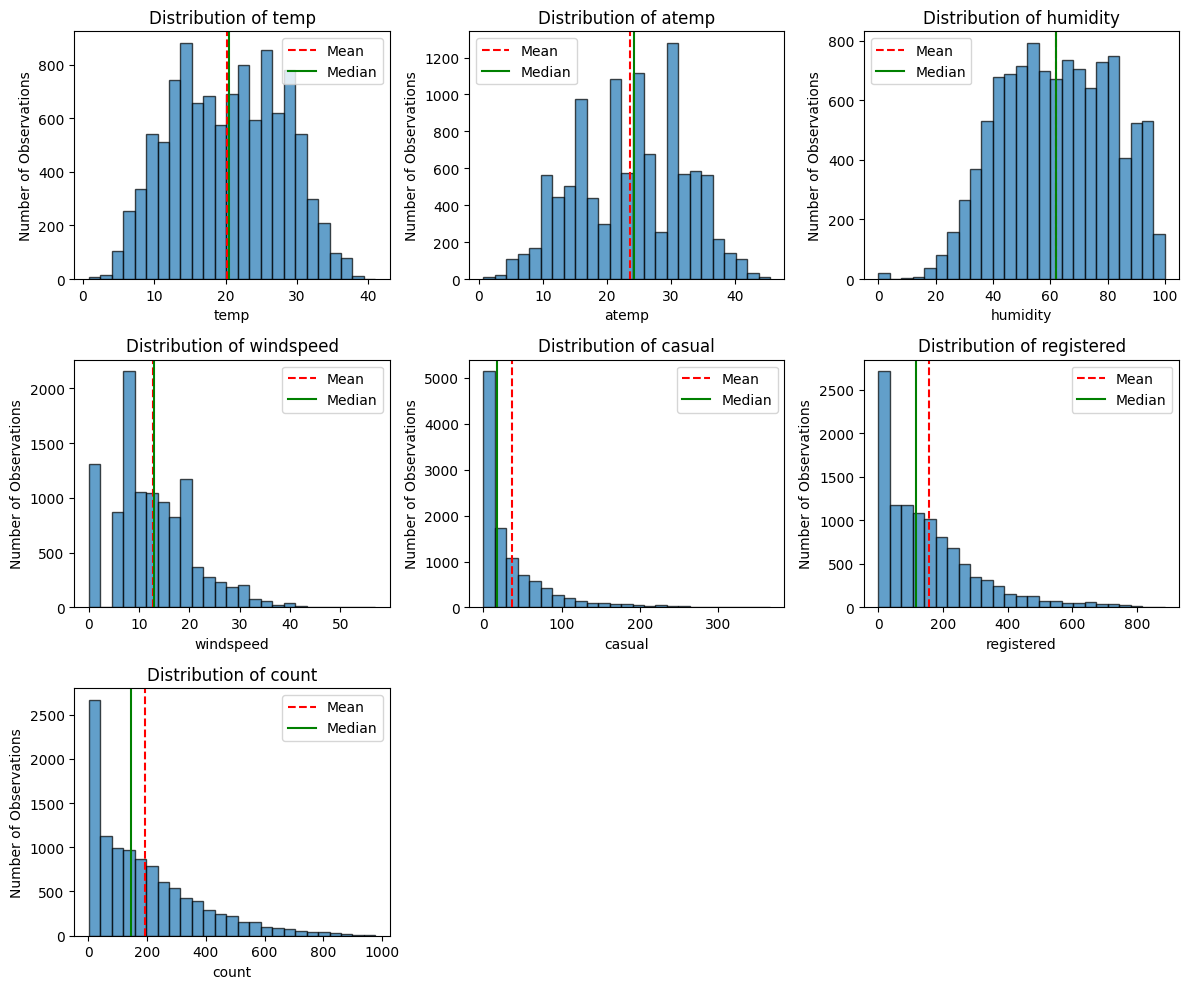

In [8]:
# Create histograms for numerical variables with mean and median lines
plt.figure(figsize=(12, 10))

# Loop through numerical columns and create histograms with mean and median lines
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    plt.hist(df[col], bins=25, edgecolor='black', alpha=0.7)

    # Mean & Median
    plt.axvline(df[col].mean(), linestyle='--', color='red', label='Mean')
    plt.axvline(df[col].median(), linestyle='-', color='green', label='Median')

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Observations")
    plt.legend()

plt.tight_layout()
plt.show()

**2-Box Plots of Numerical Variables**

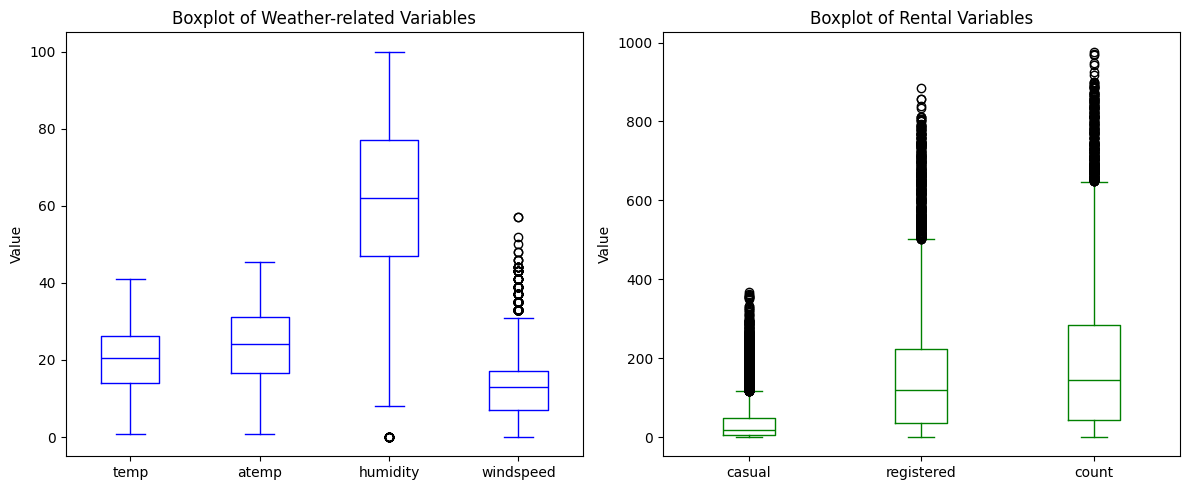

In [9]:
# Create boxplots for numerical variables to visualize outliers and distribution
# Separate boxplots for weather-related variables and rental variables for better clarity
small_cols = ["temp", "atemp", "humidity", "windspeed"]
large_cols = ["casual", "registered", "count"]

fig = plt.figure(figsize=(12, 5))

# Left subplot
ax1 = plt.subplot(1, 2, 1)
df[small_cols].plot(kind="box", ax=ax1, color="blue")
ax1.set_title("Boxplot of Weather-related Variables")
ax1.set_ylabel("Value")

# Right subplot
ax2 = plt.subplot(1, 2, 2)
df[large_cols].plot(kind="box", ax=ax2, color="green")
ax2.set_title("Boxplot of Rental Variables")
ax2.set_ylabel("Value")

plt.tight_layout()
plt.show()

The histograms show that temperature and atemp are fairly spread, while humidity and wind speed are slightly skewed. Most wind speed values are low.

The rental variables (casual, registered, and total count) are skewed, with most values being small and a few very large ones.

The boxplots show several outliers, especially for the rental variables. This means there are some times with very high bike demand.

Overall, weather variables are more stable, while bike rentals vary a lot across the data.

## 6. Categorical Analysis

This section explores the distribution of categorical variables and their relationship with bike rental activity.

Bar charts and pie charts are used to visualize how observations and average rental counts vary across different categories.

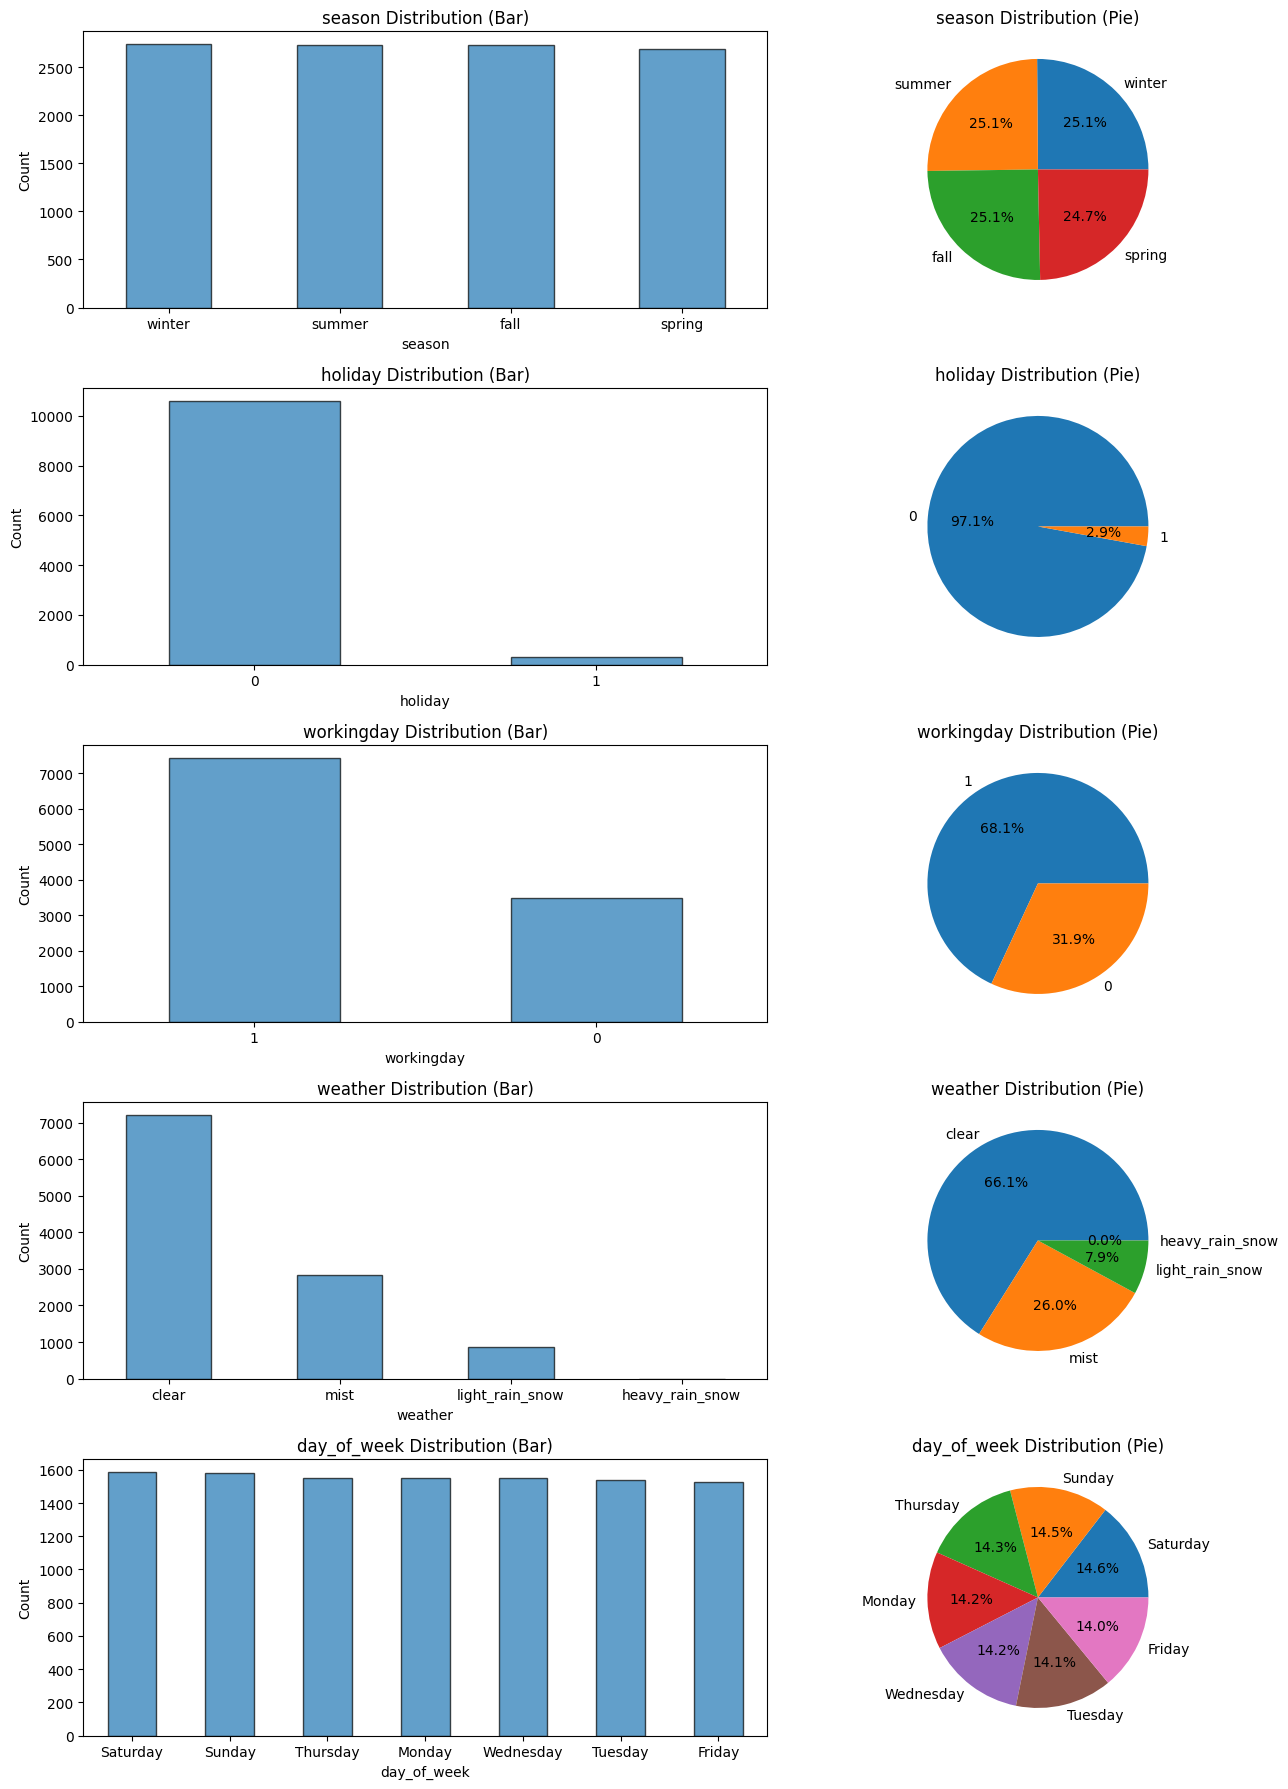

In [10]:
# Create bar plots and pie charts for categorical variables to visualize distribution
cols = ["season", "holiday", "workingday", "weather", "day_of_week"]

plt.figure(figsize=(14, 18))

for i, col in enumerate(cols):
    # Bar plot
    plt.subplot(5, 2, 2*i + 1)
    df[col].value_counts().plot(kind="bar", edgecolor='black', alpha=0.7, rot=0)
    plt.title(f"{col} Distribution (Bar)")
    plt.xlabel(col)
    plt.ylabel("Count")

    # Pie chart
    plt.subplot(5, 2, 2*i + 2)
    df[col].value_counts().plot(kind="pie",autopct="%1.1f%%")
    plt.title(f"{col} Distribution (Pie)")
    plt.ylabel("")  

plt.tight_layout()
plt.show()

These plots show how the categorical data is distributed.

Bar charts show counts, and pie charts show proportions.

Some variables, like season, are balanced, while others, like holiday, are not.

## 7. Grouped Analysis

This section groups the data by different categories, computes summary statistics, and creates plots to compare rental patterns across groups.

**1-Summary Statistics by Group**  

This section shows summary statistics of bike rentals (count) for different categories such as season, weather, working day, day of the week, and holiday.

In [11]:
# Descriptive statistics for season in terms of count
grouped_season = df.groupby("season")
describe_season_count = grouped_season["count"].describe().round(2)
print("Descriptive statistics by season in terms of count:")
print(describe_season_count)
print("-" * 60)

# Descriptive statistics for weather in terms of count
grouped_weather = df.groupby("weather")
describe_weather_count = grouped_weather["count"].describe().round(2)
print("Descriptive statistics by weather in terms of count:")
print(describe_weather_count)
print("-" * 60)

# Descriptive statistics for workingday in terms of count
grouped_workingday = df.groupby("workingday")
describe_workingday_count = grouped_workingday["count"].describe().round(2)
print("Descriptive statistics by workingday in terms of count:")
print(describe_workingday_count)
print("-" * 60)


Descriptive statistics by season in terms of count:
         count    mean     std  min   25%    50%    75%    max
season                                                        
fall    2733.0  234.42  197.15  1.0  68.0  195.0  347.0  977.0
spring  2686.0  116.34  125.27  1.0  24.0   78.0  164.0  801.0
summer  2733.0  215.25  192.01  1.0  49.0  172.0  321.0  873.0
winter  2734.0  198.99  177.62  1.0  51.0  161.0  294.0  948.0
------------------------------------------------------------
Descriptive statistics by weather in terms of count:
                  count    mean     std    min    25%    50%    75%    max
weather                                                                   
clear            7192.0  205.24  187.96    1.0   48.0  161.0  305.0  977.0
heavy_rain_snow     1.0  164.00     NaN  164.0  164.0  164.0  164.0  164.0
light_rain_snow   859.0  118.85  138.58    1.0   23.0   71.0  161.0  891.0
mist             2834.0  178.96  168.37    1.0   41.0  134.0  264.0  890.0
------

In [12]:
# Descriptive statistics for day_of_week in terms of count
grouped_day_of_week = df.groupby("day_of_week")
describe_day_of_week_count = grouped_day_of_week["count"].describe().round(2)
print("Descriptive statistics by day_of_week in terms of count:")
print(describe_day_of_week_count)
print("-" * 60)

# Descriptive statistics for holiday in terms of count
grouped_holiday = df.groupby("holiday")
describe_holiday_count = grouped_holiday["count"].describe().round(2)
print("Descriptive statistics by holiday in terms of count:")
print(describe_holiday_count)
print("-" * 60)

Descriptive statistics by day_of_week in terms of count:
              count    mean     std  min   25%    50%    75%    max
day_of_week                                                        
Friday       1529.0  197.84  172.52  1.0  52.0  167.0  290.0  900.0
Monday       1551.0  190.39  180.94  1.0  39.0  146.0  277.5  968.0
Saturday     1584.0  196.67  180.92  1.0  45.0  141.5  309.5  783.0
Sunday       1579.0  180.84  167.02  1.0  43.0  119.0  298.0  757.0
Thursday     1553.0  197.30  187.61  1.0  44.0  155.0  280.0  901.0
Tuesday      1539.0  189.72  186.72  1.0  36.0  146.0  274.0  970.0
Wednesday    1551.0  188.41  190.94  1.0  38.0  136.0  270.5  977.0
------------------------------------------------------------
Descriptive statistics by holiday in terms of count:
           count    mean     std  min   25%    50%    75%    max
holiday                                                         
0        10575.0  191.74  181.51  1.0  43.0  145.0  283.0  977.0
1          311.0  185.

**2-Average Bike Rentals by Season and Weather**

**2-1-‌Barplot**

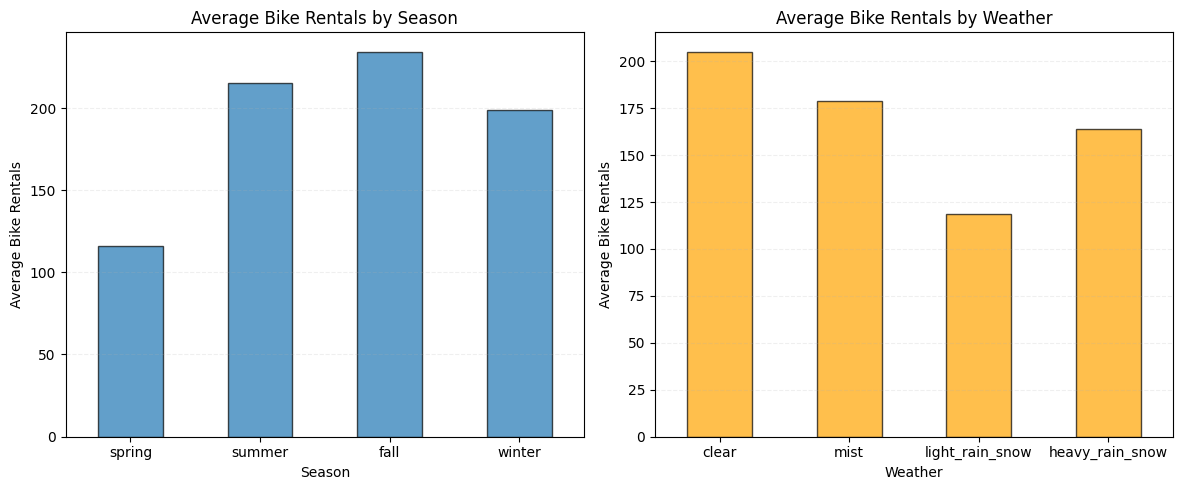

In [13]:
# Create bar plots to visualize mean rentals by season and weather
# Season
season_mean = grouped_season["count"].mean()
# Reorder seasons for better readability
season_order = ["spring", "summer", "fall", "winter"]     
season_mean = season_mean.reindex(season_order)

# Plot mean rentals by season
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
season_mean.plot(kind="bar", edgecolor='black', alpha=0.7, rot=0)
plt.title("Average Bike Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Average Bike Rentals")
plt.grid(axis='y',linestyle='--', alpha=0.2)

# Weather
weather_mean = grouped_weather["count"].mean()
# Reorder weather categories for better readability
weather_order = ["clear", "mist", "light_rain_snow", "heavy_rain_snow"]
weather_mean = weather_mean.reindex(weather_order)

# Plot mean rentals by weather
plt.subplot(1, 2, 2)
weather_mean.plot(kind="bar", edgecolor='black', alpha=0.7, rot=0, color='orange')
plt.title("Average Bike Rentals by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Bike Rentals")
plt.grid(axis='y',linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()


Bike rentals are lowest in spring and increase in summer, reaching the highest level in fall, then slightly decrease in winter.

In terms of weather, rentals are highest on clear days and decrease as weather conditions worsen, with the lowest usage during light rain or snow.

**2-2-Box plot**

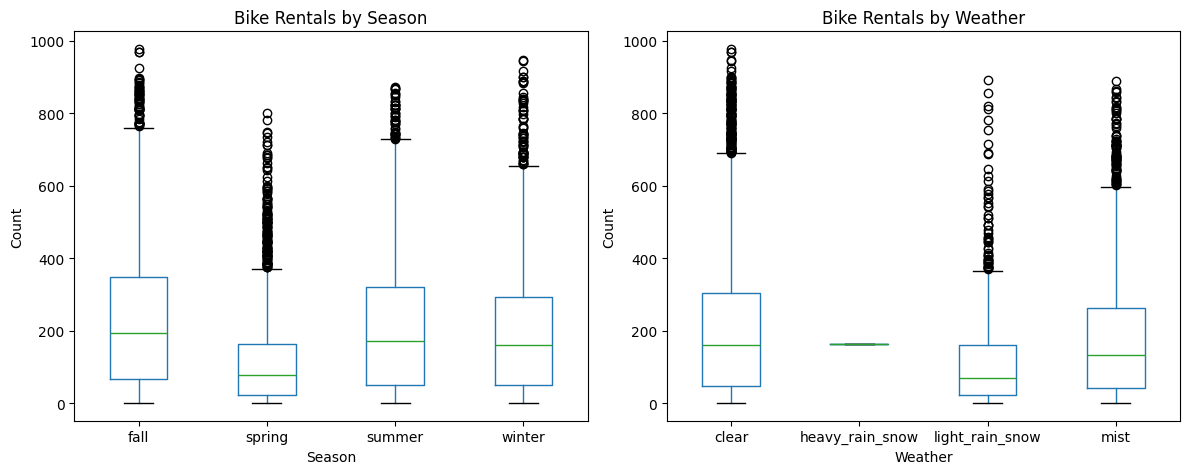

In [14]:
# Create boxplots for count by season and weather to visualize distribution and outliers
plt.figure(figsize=(12,5))

# Season
ax1 = plt.subplot(1, 2, 1)
df.boxplot(column="count", by="season", ax=ax1, grid=False)
ax1.set_title("Bike Rentals by Season")
ax1.set_xlabel("Season")
ax1.set_ylabel("Count")

# Weather
ax2 = plt.subplot(1, 2, 2)
df.boxplot(column="count", by="weather", ax=ax2, grid=False)
ax2.set_title("Bike Rentals by Weather")
ax2.set_xlabel("Weather")
ax2.set_ylabel("Count")

plt.suptitle("")
plt.tight_layout()
plt.show()

The distribution of bike rentals varies across seasons, with higher values and more variability in summer and fall.

In terms of weather, rentals are generally higher on clear days and lower during rainy or snowy conditions.

**3- Average Bike Rentals by Season and Day Type**

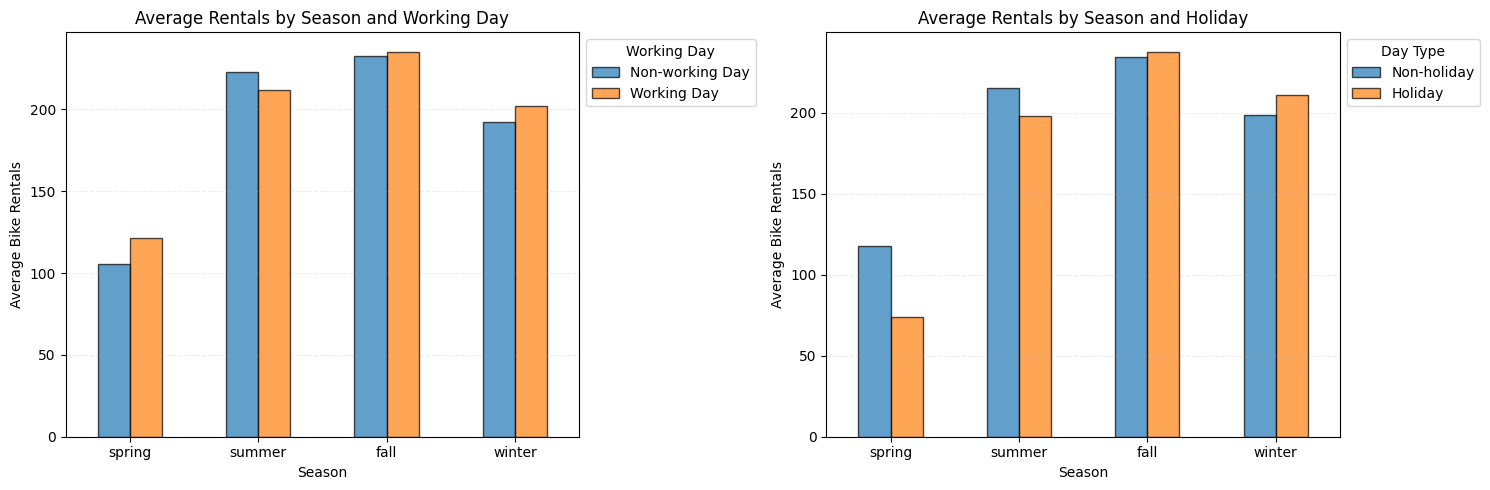

In [15]:
# Group by season with working day and holiday, then compute average rentals
season_workingday = df.groupby(["season", "workingday"])["count"].mean().unstack()
season_holiday = df.groupby(["season", "holiday"])["count"].mean().unstack()

# Reorder and rename columns for better readability
season_workingday = season_workingday.sort_index(axis=1)
season_holiday = season_holiday.sort_index(axis=1)

season_workingday.columns = ["Non-working Day", "Working Day"]
season_holiday.columns = ["Non-holiday", "Holiday"]

# Reorder seasons for better readability
season_order = ["spring", "summer", "fall", "winter"]
season_workingday = season_workingday.reindex(season_order)
season_holiday = season_holiday.reindex(season_order)

plt.figure(figsize=(15,5))

# Plot season with working day
ax1 = plt.subplot(1, 2, 1)
season_workingday.plot(kind="bar", rot=0, edgecolor='black', alpha=0.7, ax=ax1)
plt.title("Average Rentals by Season and Working Day")
plt.xlabel("Season")
plt.ylabel("Average Bike Rentals")
plt.grid(axis='y',linestyle='--', alpha=0.2)
plt.legend(title="Working Day", bbox_to_anchor=(1, 1), loc='upper left')

# Plot season with holiday
ax2 = plt.subplot(1, 2, 2)
season_holiday.plot(kind="bar", edgecolor='black', alpha=0.7, rot=0, ax=ax2)
plt.title("Average Rentals by Season and Holiday")
plt.xlabel("Season")
plt.ylabel("Average Bike Rentals")
plt.grid(axis='y',linestyle='--', alpha=0.2)
plt.legend(title="Day Type", bbox_to_anchor=(1,1))

plt.tight_layout()
plt.show()

Bike rentals are usually higher on working days than on non-working days in most seasons.

Rentals are highest in summer and fall, while spring has the lowest levels.

Rentals are generally lower on holidays than on non-holidays in spring and summer.

In fall and winter, the difference is smaller, and holiday rentals can be similar or slightly higher.

**4-Average Bike Rentals by Working Day and Weather**

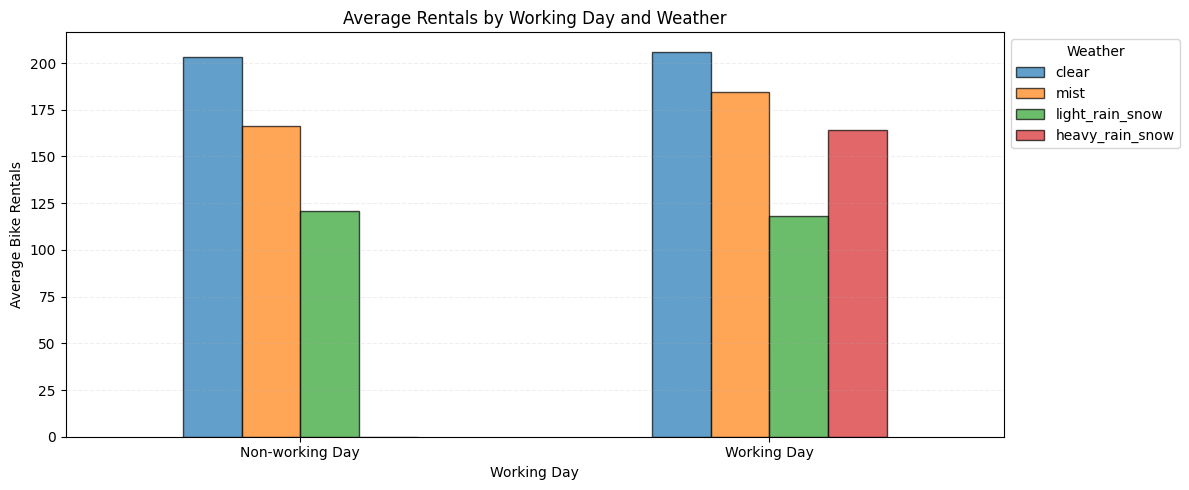

In [16]:
# Group by working day and weather, then compute average rentals
wd_weather = df.groupby(["workingday", "weather"])["count"].mean().unstack()

# Reorder and rename index for better readability
wd_weather = wd_weather.sort_index()
wd_weather.index = ["Non-working Day", "Working Day"]

# Reorder weather columns for better readability
weather_order = ["clear", "mist", "light_rain_snow", "heavy_rain_snow"]
wd_weather = wd_weather[weather_order]

# Plot
wd_weather.plot(kind="bar", figsize=(12,5), rot=0, edgecolor='black', alpha=0.7)
plt.title("Average Rentals by Working Day and Weather")
plt.xlabel("Working Day")
plt.ylabel("Average Bike Rentals")
plt.grid(axis='y',linestyle='--', alpha=0.2)
plt.legend(title="Weather", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Bike rentals are usually higher on working days than on non-working days across most weather conditions.

Rentals are highest in clear weather, and they decrease as weather conditions get worse.

**5- Casual vs Registered Rentals by Working Day and Holiday**

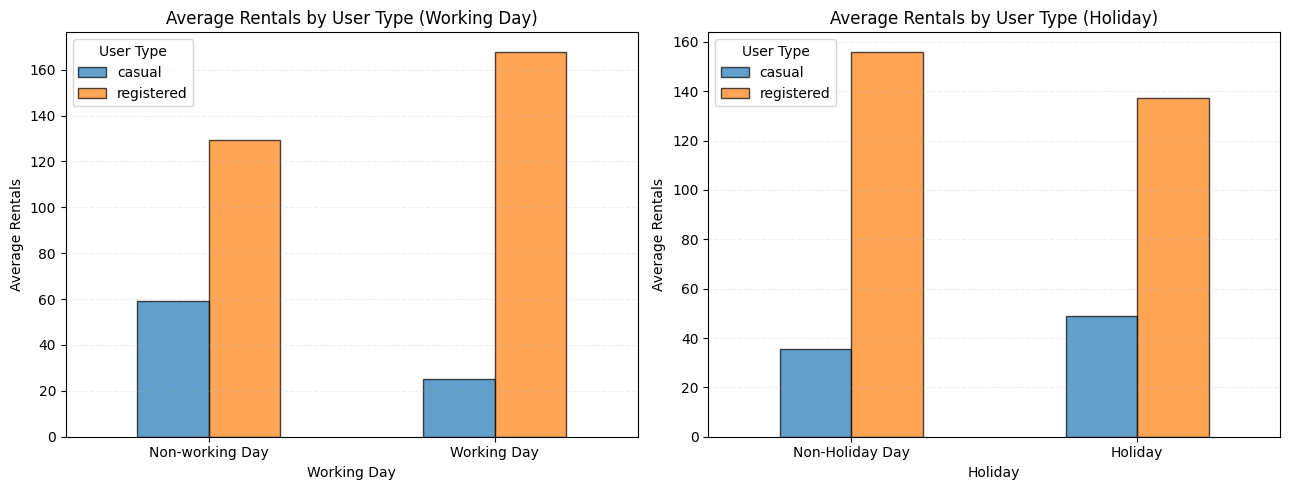

In [17]:
# Average rentals by working day for both user types
user_summary = df.groupby("workingday")[["casual", "registered"]].mean()
# Average rentals by holiday day for both user types
holiday_summary = df.groupby("holiday")[["casual", "registered"]].mean()

# Plot average rentals by workingday and holiday for both user types
plt.figure(figsize=(13, 5))

# Plot by working day
ax1 = plt.subplot(1, 2, 1)
user_summary.plot(kind="bar", edgecolor='black', alpha=0.7, ax=ax1)
plt.title("Average Rentals by User Type (Working Day)")
plt.xlabel("Working Day")
plt.ylabel("Average Rentals")
plt.xticks(ticks=[0, 1], labels=["Non-working Day", "Working Day"], rotation=0)
plt.grid(axis="y", linestyle='--', alpha=0.2)
plt.legend(title="User Type")

# Plot by holiday day
ax2 = plt.subplot(1, 2, 2)
holiday_summary.plot(kind="bar", edgecolor='black', alpha=0.7, ax=ax2)
plt.title("Average Rentals by User Type (Holiday)")
plt.xlabel("Holiday")
plt.ylabel("Average Rentals")
plt.xticks(ticks=[0, 1], labels=["Non-Holiday Day", "Holiday"], rotation=0)
plt.grid(axis="y", linestyle='--', alpha=0.2)
plt.legend(title="User Type")

plt.tight_layout()
plt.show()

The bar charts compare casual and registered users across working days and holidays.

Casual rentals are higher on non-working days, while registered rentals are higher on working days. This suggests that casual users are more active during leisure time, while registered users are more active for daily travel.

For holidays, a similar pattern is seen, with slightly higher casual usage than on regular days. However, since holidays are rare in the dataset, this result should be interpreted with caution.

**6-Average Bike Rentals by Season and Day of Week**

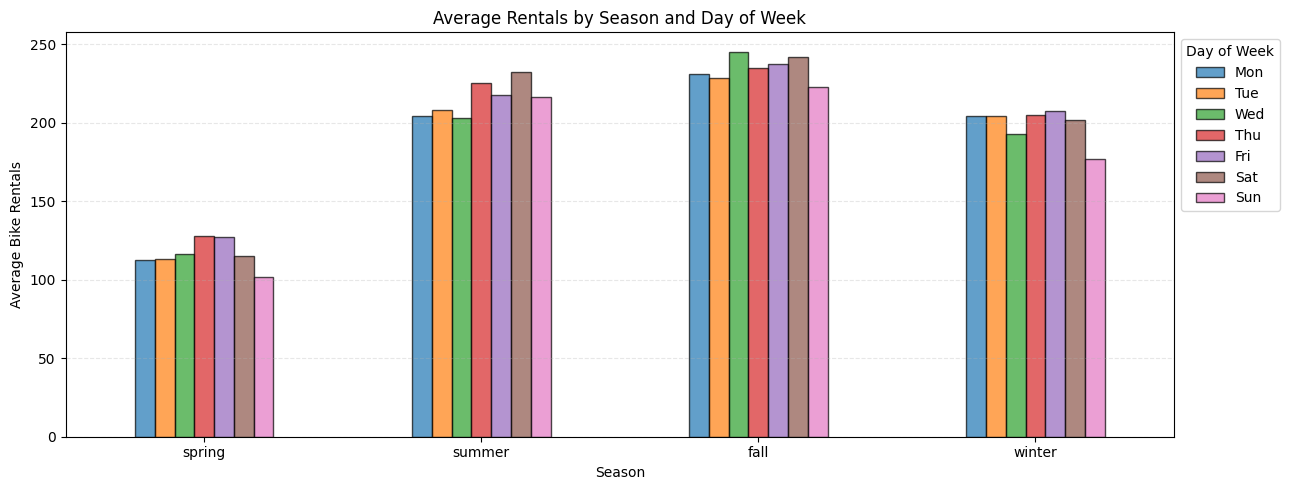

In [18]:
# Group by season and day of week, then compute average rentals
season_day = df.groupby(["season", "day_of_week"])["count"].mean().unstack()

# Reorder days  for better readability
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
season_day = season_day[order]

# Shorten day names for cleaner legend
season_day.columns = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# Reorder seasons for better readability
season_order = ["spring", "summer", "fall", "winter"]
season_day = season_day.reindex(season_order)

# Plot
season_day.plot(kind="bar", figsize=(13,5), rot=0, edgecolor='black', alpha=0.7)
plt.title("Average Rentals by Season and Day of Week")
plt.xlabel("Season")
plt.ylabel("Average Bike Rentals")
plt.grid(axis='y',linestyle='--', alpha=0.3)
plt.legend(title="Day of Week", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Bike rentals are slightly higher on weekdays than on weekends in most seasons.

Rentals are highest in summer and fall, while spring has the lowest levels.

In most seasons, rentals are a bit lower on Sundays, especially in spring and winter. In summer, Sunday rentals are closer to weekdays.

## 8. Feature Engineering

This section creates new features based on patterns in the data to better represent bike rental behavior.

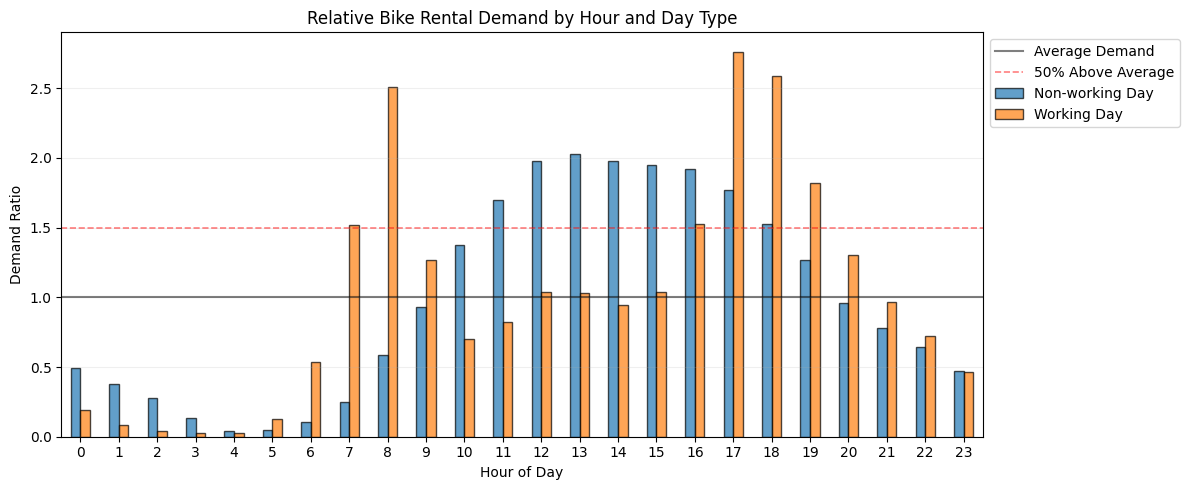

In [19]:
# Compute relative demand 
ratio_hour = (df.groupby(["hour", "workingday"])["count"].mean() / df["count"].mean()).unstack()

# Rename columns for a clearer legend
ratio_hour.columns = ["Non-working Day", "Working Day"]

# Plot
ratio_hour.plot(kind="bar", figsize=(12, 5), edgecolor="black", alpha=0.7, rot=0)
plt.title("Relative Bike Rental Demand by Hour and Day Type")
plt.xlabel("Hour of Day")
plt.ylabel("Demand Ratio")

# Reference lines
plt.axhline(1, color="black", label="Average Demand", alpha=0.5)
plt.axhline(1.5, color="red", linestyle="--", linewidth = 1.2, label="50% Above Average", alpha=0.5)

plt.grid(axis="y", alpha=0.2)
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.tight_layout()
plt.show()

The plot shows how bike rental demand changes across hours of the day for working and non-working days.

Demand is higher on working days, especially around 7–9 AM and 4–7 PM, which likely match commuting hours.

On non-working days, demand is higher in the middle of the day, roughly from 10 AM to 6 PM, rather than early morning or late evening.

Overall, both time of day and working day have a strong effect on bike rental demand.  

Based on patterns in the data, a new feature called "peak_period" is created.

This feature combines hour and working day to capture different demand patterns, such as morning and evening peaks on working days and midday peaks on non-working days.

In [20]:
# Default: non-peak
df["peak_period"] = "Non-peak" 

# Working day peaks 
df.loc[(df["workingday"] == 1) & (df["hour"].between(7, 9)), "peak_period"] = "WD-Morning Peak"    # morning peak in working days
df.loc[(df["workingday"] == 1) & (df["hour"].between(16, 19)), "peak_period"] = "WD-Evening Peak"  # evening peak in working days

# Non-working day peak 
df.loc[(df["workingday"] == 0) & (df["hour"].between(10, 18)), "peak_period"] = "NWD-Midday Peak"  # midday peak in non-working days

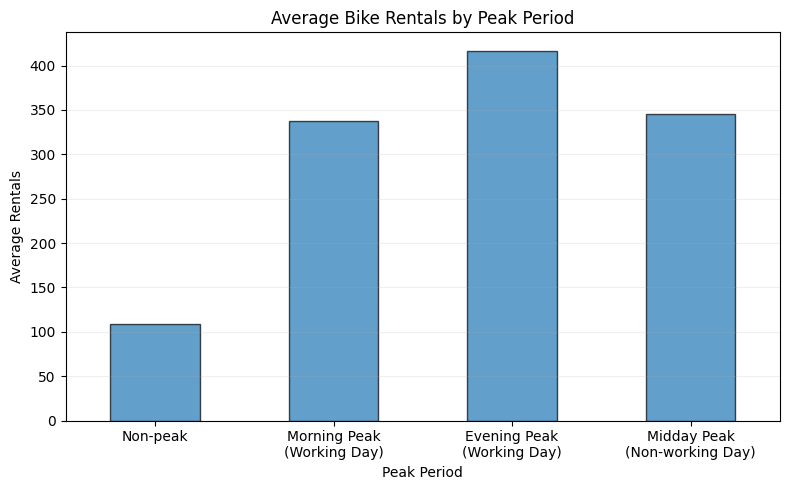

In [21]:
# Average rentals by peak periods
peak_order = ["Non-peak","WD-Morning Peak","WD-Evening Peak","NWD-Midday Peak"]
peak_summary = df.groupby("peak_period")["count"].mean().reindex(peak_order)

# Plot average rentals by peak periods
plt.figure(figsize=(8, 5))
peak_summary.plot(kind="bar", edgecolor="black", alpha=0.7)
plt.title("Average Bike Rentals by Peak Period")
plt.xlabel("Peak Period")
plt.ylabel("Average Rentals")
plt.xticks(ticks=range(len(peak_summary)),labels=["Non-peak","Morning Peak\n(Working Day)","Evening Peak\n(Working Day)","Midday Peak\n(Non-working Day)"],rotation=0)

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

The plot shows the average number of rentals for different peak periods.

Evening peak hours on working days have the highest demand, followed by morning peaks.

On non-working days, demand is higher during the middle of the day compared to other times.

This shows that combining hour and working day helps better capture bike rental patterns.

## 9. Trends Over Time

This section shows how bike rentals change over time using daily, weekly, and monthly trends. It also compares rentals across days of the week and shows how rentals change with temperature and humidity.

**1-Bike Rental Trends at Different Time Scales**

C:\Users\roozb\AppData\Local\Temp\ipykernel_17868\2942147230.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df["count"].resample("M").mean().dropna()


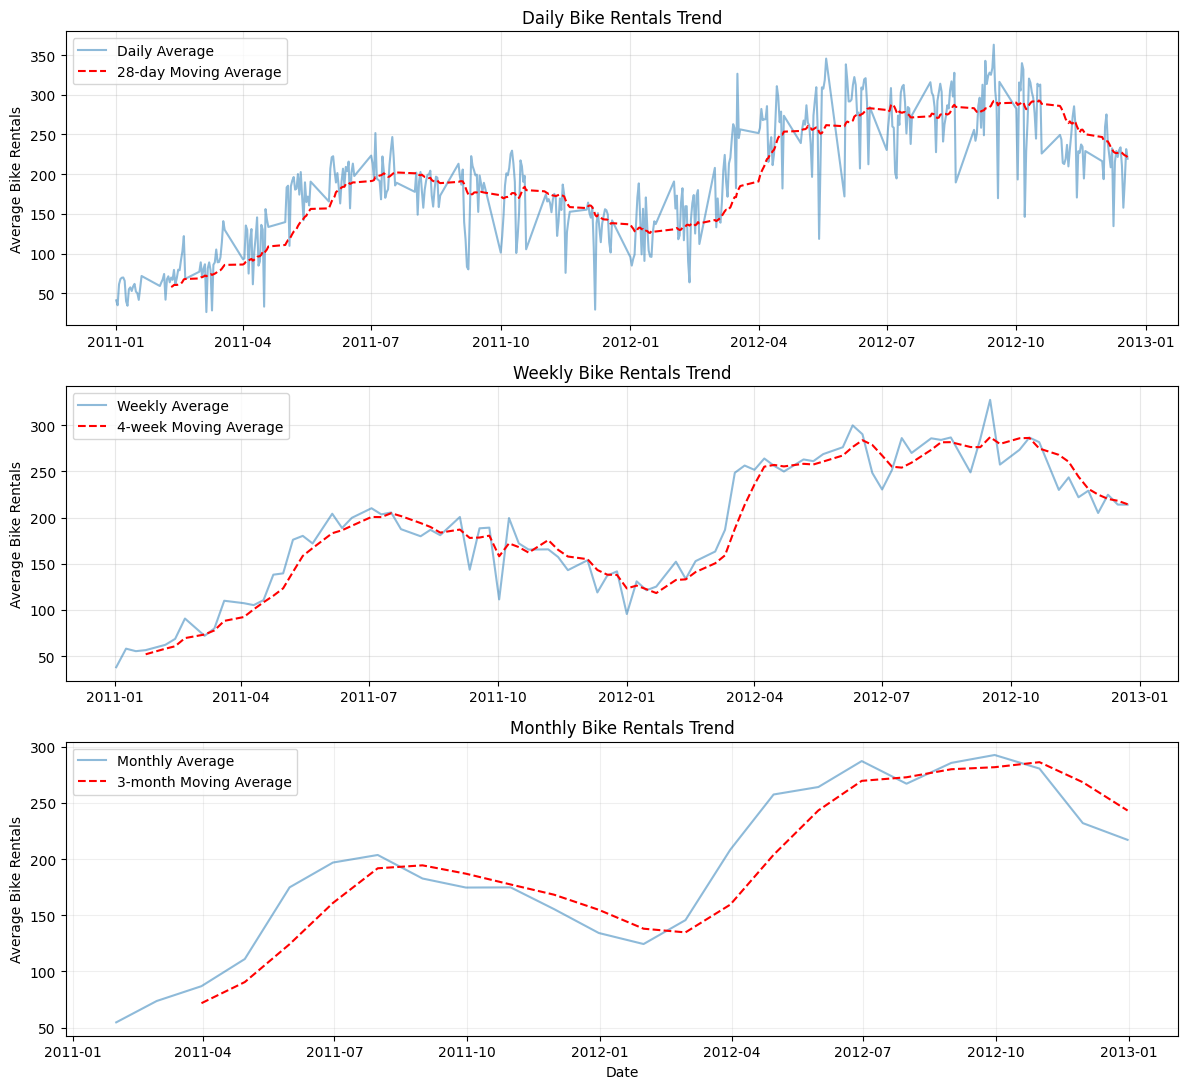

In [22]:
# Create daily, weekly, and monthly time series
# Daily average rentals
df_daily = df["count"].resample("D").mean().dropna()
df_daily_roll = df_daily.rolling(28).mean()  # 28-day (~ 4-week trend) moving average

# Weekly average rentals
df_weekly = df["count"].resample("W").mean().dropna()
df_weekly_roll = df_weekly.rolling(4).mean()  # 4-week trend (~ 1-month trend) moving average 

# Monthly average rentals
df_monthly = df["count"].resample("M").mean().dropna()
df_monthly_roll = df_monthly.rolling(3).mean()  # 3-month moving average 

# Plot time series with rolling averages
plt.figure(figsize=(12,11))

# Daily
plt.subplot(3,1,1)
plt.plot(df_daily, label="Daily Average", alpha=0.5)
plt.plot(df_daily_roll, label="28-day Moving Average", linestyle="--", color="red")
plt.title("Daily Bike Rentals Trend")
plt.ylabel("Average Bike Rentals")
plt.legend()
plt.grid(alpha=0.3)

# Weekly
plt.subplot(3,1,2)
plt.plot(df_weekly, label="Weekly Average", alpha=0.5)
plt.plot(df_weekly_roll, label="4-week Moving Average", linestyle="--", color="red")
plt.title("Weekly Bike Rentals Trend")
plt.ylabel("Average Bike Rentals")
plt.legend()
plt.grid(alpha=0.3)

# Monthly
plt.subplot(3,1,3)
plt.plot(df_monthly, label="Monthly Average", alpha=0.5)
plt.plot(df_monthly_roll, label="3-month Moving Average", linestyle="--", color="red")
plt.title("Monthly Bike Rentals Trend")
plt.xlabel("Date")
plt.ylabel("Average Bike Rentals")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show();

These plots show bike rentals over time at daily, weekly, and monthly levels.

At all levels, rentals increase from the beginning of the year to the middle, and then decrease toward the end of the year.

The moving average lines make the overall trend easier to see by reducing short-term changes.

This shows a clear seasonal pattern, with higher rentals in warmer months and lower rentals in colder months.

**2-Weekly Pattern (Day of Week)**

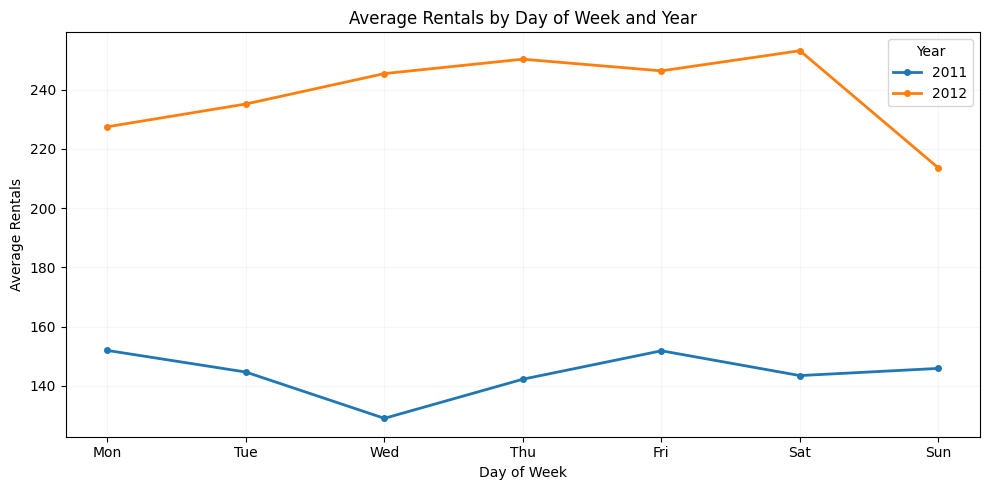

In [23]:
# Average rentals by day of week and year to see if weekday patterns changed over years
# Reorder days of week for better readability
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Group by day of week and year, then compute average rentals 
day_year = df.groupby(["day_of_week", "year"])["count"].mean().unstack().reindex(day_order)

# Plot
plt.figure(figsize=(10, 5))
day_year.plot(ax=plt.gca(), marker="o", linewidth=2, markersize=4)
plt.xticks(ticks=range(len(day_order)), labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.title("Average Rentals by Day of Week and Year")
plt.xlabel("Day of Week")
plt.ylabel("Average Rentals")
plt.grid(alpha=0.1)
plt.legend(title="Year", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

The plot shows how bike rentals change across days of the week for different years.

Rentals in 2012 are higher than in 2011 on all days.

The differences between days are small. Rentals are slightly higher on Friday and Saturday and lower on Sunday.

Overall, weekly patterns exist, but they are weaker than seasonal trends.

**3-Monthly Trends (Rentals and Weather)**

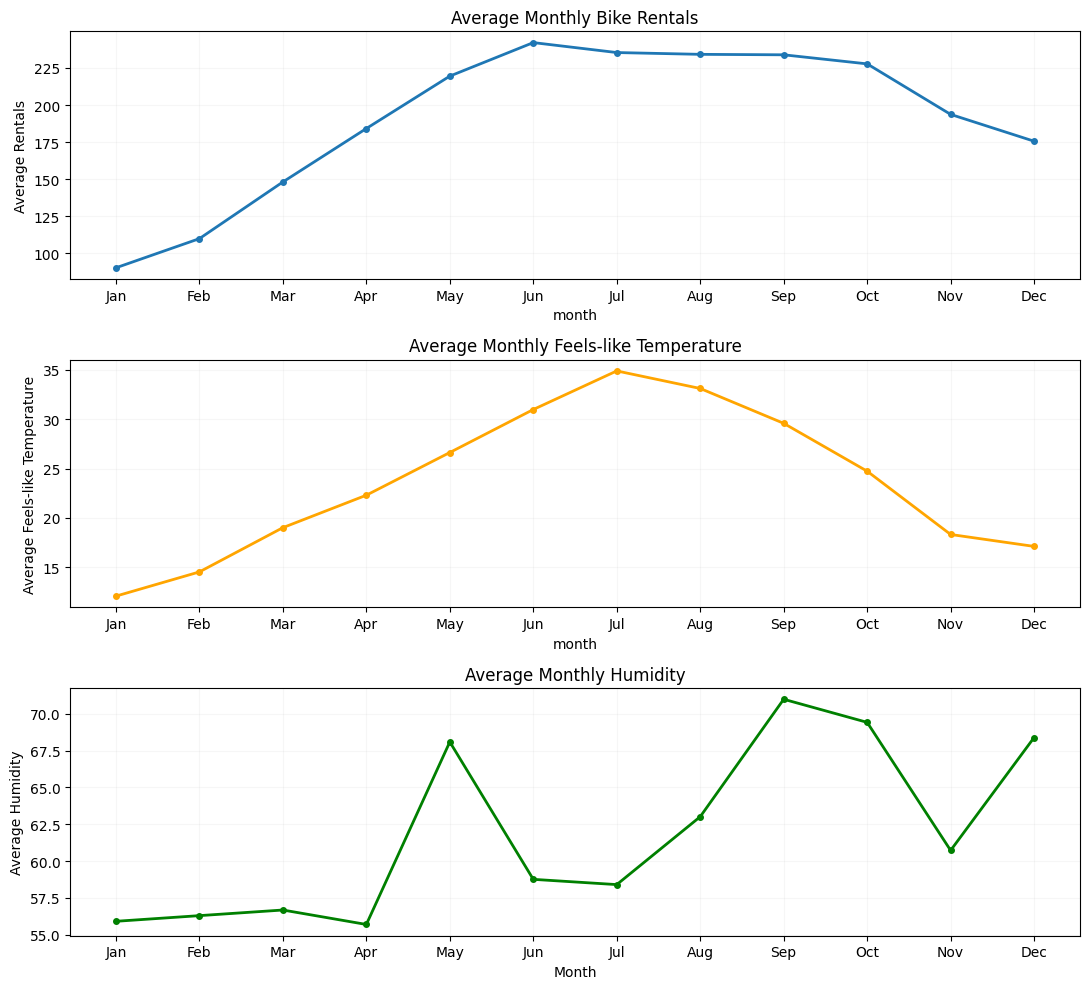

In [24]:
# Average rentals, atemp, and humidity by month to see if seasonal patterns changed over years
df_monthly = df.groupby("month")[["count", "atemp", "humidity"]].mean()

# Month labels
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun","Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Subplots
fig, axes = plt.subplots(3, 1, figsize=(11, 10))

# Plot 1-rentals
df_monthly["count"].plot(ax=axes[0], marker="o", linewidth=2, markersize=4)
axes[0].set_title("Average Monthly Bike Rentals")
axes[0].set_ylabel("Average Rentals")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels)
axes[0].grid(alpha=0.1)

# Plot 2-temperature
df_monthly["atemp"].plot(ax=axes[1], color='orange', marker="o", linewidth=2, markersize=4)
axes[1].set_title("Average Monthly Feels-like Temperature")
axes[1].set_ylabel("Average Feels-like Temperature")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels)
axes[1].grid(alpha=0.1)

# Plot 3-humidity
df_monthly["humidity"].plot(ax=axes[2], color='green', marker="o", linewidth=2, markersize=4)
axes[2].set_title("Average Monthly Humidity")
axes[2].set_ylabel("Average Humidity")
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(month_labels)
axes[2].set_xlabel("Month")
axes[2].grid(alpha=0.1)

plt.tight_layout()
plt.show()


These plots show how bike rentals, temperature, and humidity change over the months.

Bike rentals increase from winter to summer, peak around June, and then decrease toward the end of the year. This shows a clear seasonal pattern.

Feels-like temperature follows a similar pattern. As temperature increases, bike rentals also increase.

Humidity changes over the year, but the pattern is not very clear.

Overall, warmer weather is linked to higher bike rentals, while humidity does not seem to have a strong effect.

## 10. Variable Relationships

This section explores the relationships between variables.

Correlation values and scatter plots are used to understand how different features are related to bike rentals.

**1-Correlation Matrix of Numerical Features**

In [25]:
# Correlation matrix for numerical variables
num_cols = ["temp", "atemp", "humidity", "windspeed", "casual", "registered", "count"]
corr_matrix = df[num_cols].corr()
print("Correlation matrix:\n")
print(corr_matrix)

Correlation matrix:

                temp     atemp  humidity  windspeed    casual  registered  \
temp        1.000000  0.984948 -0.064949  -0.017852  0.467097    0.318571   
atemp       0.984948  1.000000 -0.043536  -0.057473  0.462067    0.314635   
humidity   -0.064949 -0.043536  1.000000  -0.318607 -0.348187   -0.265458   
windspeed  -0.017852 -0.057473 -0.318607   1.000000  0.092276    0.091052   
casual      0.467097  0.462067 -0.348187   0.092276  1.000000    0.497250   
registered  0.318571  0.314635 -0.265458   0.091052  0.497250    1.000000   
count       0.394454  0.389784 -0.317371   0.101369  0.690414    0.970948   

               count  
temp        0.394454  
atemp       0.389784  
humidity   -0.317371  
windspeed   0.101369  
casual      0.690414  
registered  0.970948  
count       1.000000  


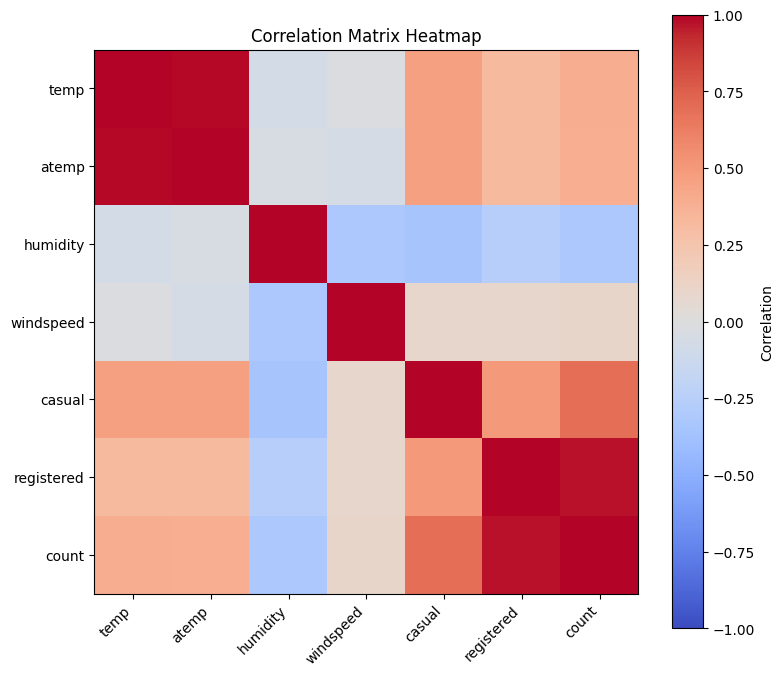

In [26]:
# Plot heat map of Correlation matrix
plt.figure(figsize=(8, 7))
im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

In [27]:
# Correlation with target (number of rentals) sorted from highest to lowest
print("Correlation of  numeric features with target (number of rentals):\n")
print(corr_matrix["count"].sort_values(ascending=False)[1:])

Correlation of  numeric features with target (number of rentals):

registered    0.970948
casual        0.690414
temp          0.394454
atemp         0.389784
windspeed     0.101369
humidity     -0.317371
Name: count, dtype: float64


**2-Scatter Plots for Numerical Features vs Target**

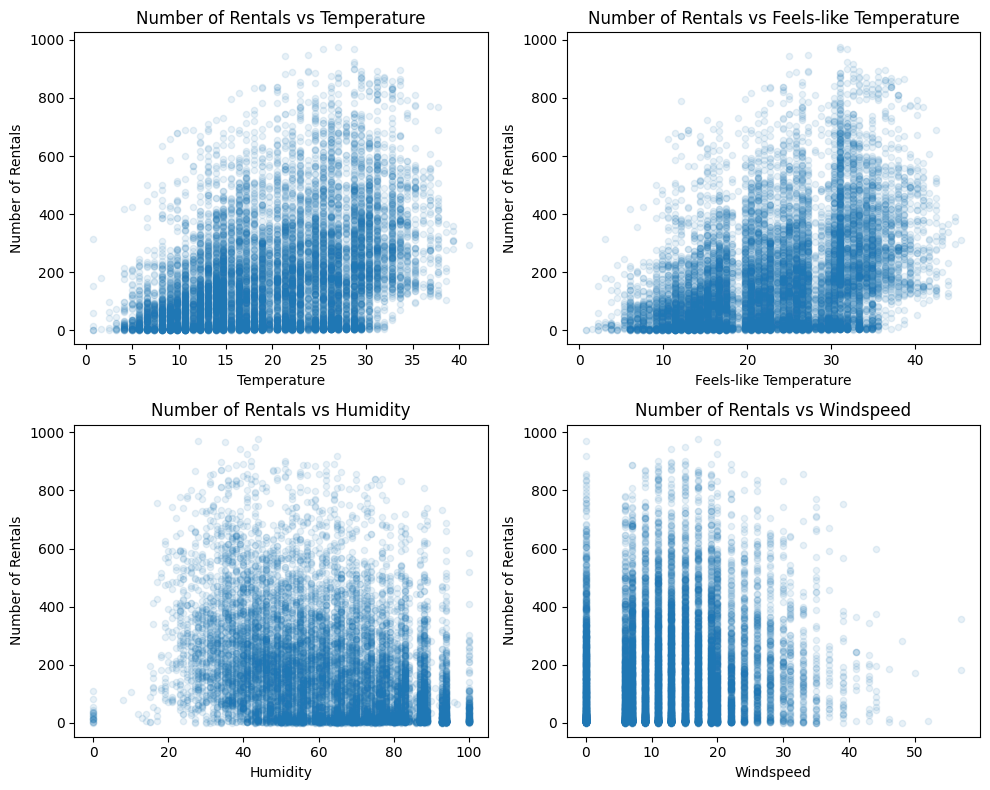

In [28]:
# Selecting features and labels for clearer plots
plot_columns = ["temp", "atemp", "humidity", "windspeed"]
label_map = {"temp": "Temperature","atemp": "Feels-like Temperature", "humidity": "Humidity","windspeed": "Windspeed"}

# Plot
plt.figure(figsize=(10, 8))
for (i, c) in enumerate(plot_columns):
    plt.subplot(2, 2, i + 1)
    df.plot.scatter(c, "count", alpha=0.1, ax=plt.gca())
    plt.xlabel(label_map[c])
    plt.ylabel("Number of Rentals")
    plt.title(f"Number of Rentals vs {label_map[c]}")

plt.tight_layout()
plt.show()

**3-Scatter Plots for Relationships Between Numerical Features (Feature vs Feature)**

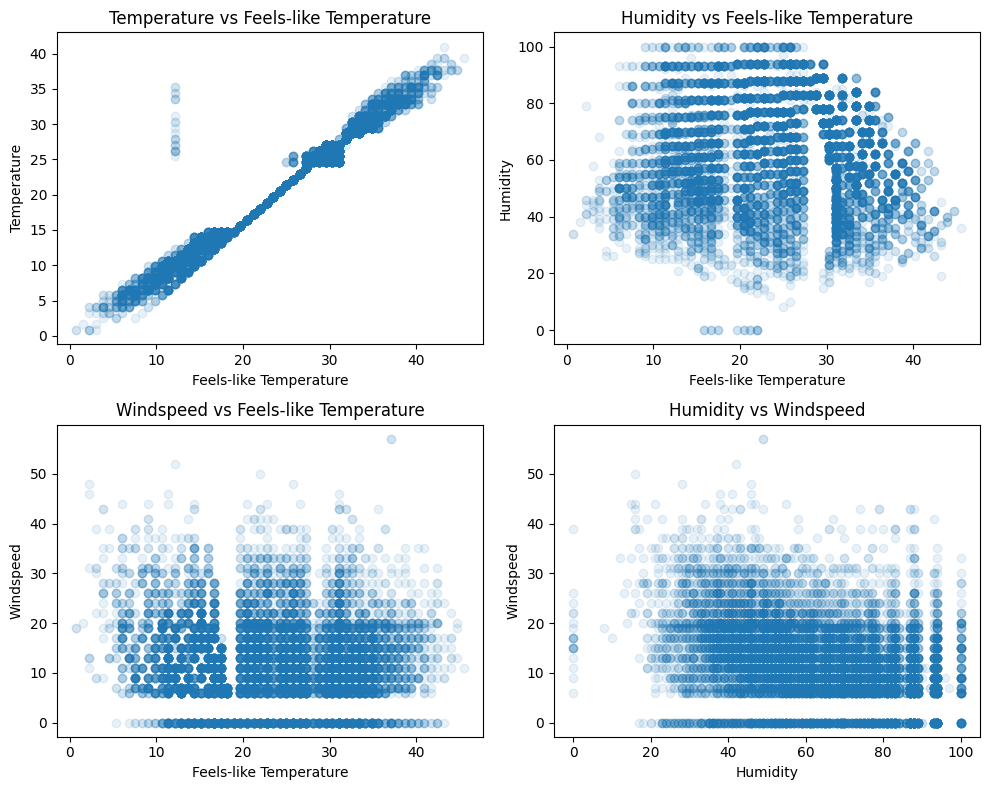

In [29]:
# Scatter plots for relationships between numerical features (feature vs feature)
plt.figure(figsize=(10,8))  

# 1-atemp vs temp (check multicollinearity)
plt.subplot(2,2,1)
plt.scatter(df["atemp"], df["temp"], alpha=0.1)
plt.xlabel("Feels-like Temperature")  
plt.ylabel("Temperature")            
plt.title("Temperature vs Feels-like Temperature")

# 2-atemp vs humidity
plt.subplot(2,2,2)
plt.scatter(df["atemp"], df["humidity"], alpha=0.1)
plt.xlabel("Feels-like Temperature")
plt.ylabel("Humidity")
plt.title("Humidity vs Feels-like Temperature")

# 3-atemp vs windspeed
plt.subplot(2,2,3)
plt.scatter(df["atemp"], df["windspeed"], alpha=0.1)
plt.xlabel("Feels-like Temperature")
plt.ylabel("Windspeed")
plt.title("Windspeed vs Feels-like Temperature")

# 4-humidity vs windspeed
plt.subplot(2,2,4)
plt.scatter(df["humidity"], df["windspeed"], alpha=0.1)
plt.xlabel("Humidity")
plt.ylabel("Windspeed")
plt.title("Humidity vs Windspeed")

plt.tight_layout()  
plt.show()          

The correlation results show that registered users have the strongest relationship with total rentals, followed by casual users.

Temperature and feels-like temperature are positively related to rentals, while humidity is negatively related and windspeed has a weak effect.

The scatter plots show that rentals increase as temperature increases and decrease as humidity increases. Windspeed does not show a clear pattern.

The feature-to-feature plots show that temperature and feels-like temperature are very strongly related, meaning they provide similar information.

**4-Average Rentals by Temperature Levels**  

To better understand the relationship between temperature and rentals, the data is grouped into temperature levels and the average rentals are compared.

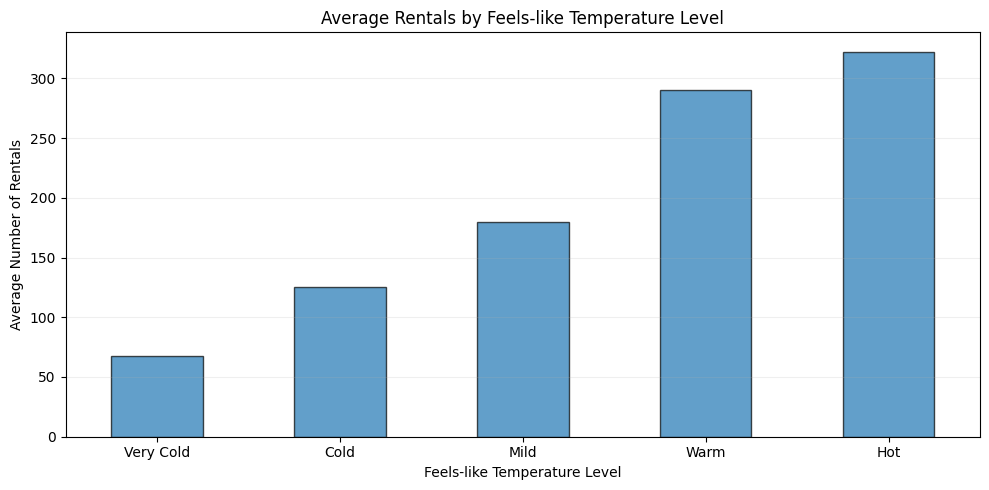

In [30]:
# Create bins for atemp to analyze rentals by temperature levels
atemp_bins = pd.cut(df["atemp"], bins=[0, 10, 20, 30, 40, 50], labels=["Very Cold", "Cold", "Mild", "Warm", "Hot"])

# Compute average rentals per bin
temp_summary = df.groupby(atemp_bins, observed=True)["count"].mean()
temp_summary = temp_summary.reindex(["Very Cold", "Cold", "Mild", "Warm", "Hot"])
# Plot
temp_summary.plot(kind="bar", figsize=(10, 5), rot=0, edgecolor="black", alpha=0.7)

plt.title("Average Rentals by Feels-like Temperature Level") 
plt.xlabel("Feels-like Temperature Level")
plt.ylabel("Average Number of Rentals")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

Bike rentals increase as temperature increases.

Rentals are lowest in very cold weather and highest in warm and hot weather.

This shows that warmer temperatures lead to higher bike rentals.

## 11. Hypothesis

**1. Bike rentals are higher during peak periods than during non-peak times.**

This may be because people use bikes more during commuting hours on working days and during the middle of the day on non-working days.

**2. Bike rentals increase as feels-like temperature increases.**

This may be because people prefer to ride bikes in warmer and more comfortable weather. Cold or extreme weather can make biking less comfortable, so fewer people choose to ride.

## 12. Linear Regression

Before building the model, the data is prepared.

* The `hour` variable is cyclical, so it is converted into `hour_sin` and `hour_cos`. This means the hours are treated like a circle, similar to a clock. For example, hour 23 and hour 0 are close in time, but their values are numerically far apart when using the original hour values. The sine and cosine transformation keeps this circular pattern, so the model can better understand the relationship between different hours.
  

* Some columns are removed before modeling:  
The `datetime` column is removed because time-based features are already created from it.  
The `hour` is removed because it is replaced by `hour_sin` and `hour_cos`.  
The `temp` column is removed because it is very similar to `atemp`, which represents the feels-like temperature and is more relevant to human behavior. 
The `casual` and `registered` columns are removed because they directly form the target variable `count`, which would cause data leakage. 
  

* Categorical variables are converted using `get_dummies()` method.  
The model needs numerical input, and assigning numbers like 1, 2, 3 to categories would create a false order. Dummy variables solve this issue by creating separate binary columns for each category.
    
* The data is then split into training and testing sets to evaluate the model on unseen data.

* Numerical features are scaled because they are on different ranges, which helps the model treat them more equally. Dummy variables are not scaled because they are already binary (0 and 1).

* Finally, a linear regression model is trained and evaluated using MSE, RMSE, and R2 score, and actual vs predicted plots are created for both the training and testing data.

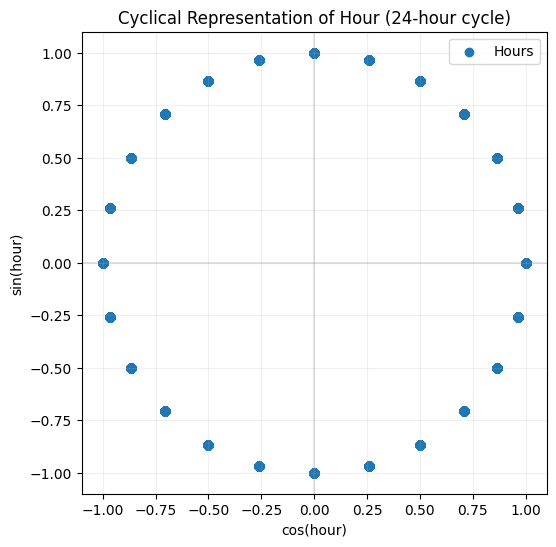

In [31]:
# Explanation of why I convert hour into a cyclical form with plot
# Convert hour into a cyclical form (like a clock), as explained above 
hour_sin = np.sin(2 * np.pi * df["hour"] / 24)
hour_cos = np.cos(2 * np.pi * df["hour"] / 24)

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(hour_cos, hour_sin, label="Hours")

plt.title("Cyclical Representation of Hour (24-hour cycle)")
plt.xlabel("cos(hour)")
plt.ylabel("sin(hour)")

plt.axhline(0, color='gray', alpha=0.2)
plt.axvline(0, color='gray', alpha=0.2)

plt.legend(bbox_to_anchor=(1, 1))
plt.grid(alpha=0.2)
plt.show()

In [32]:
# Make a copy so the original dataframe is not changed 
df_model = df.copy()

# Convert hour into cyclical features
df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)

# Drop columns that should not be used in the model
df_model = df_model.drop(columns=["datetime", "temp", "casual", "registered", "hour"])

# Convert categorical variables into dummy variables
cat_cols = ["season", "holiday", "workingday", "weather", "day_of_week", "month", "year", "peak_period"]
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# Separate features and target
X = df_model.drop("count", axis=1)
y = df_model["count"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

# Numerical columns to scale
num_cols = ["atemp", "humidity", "windspeed", "hour_sin", "hour_cos"]

# Scale only numerical features using StandardScaler (mean=0, std=1)
scaler = sklearn.preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_cols])
X_test_scaled = scaler.transform(X_test[num_cols])

# Extract dummy variables (categorical features) without scaling
X_train_cat = X_train.drop(num_cols, axis=1).values
X_test_cat = X_test.drop(num_cols, axis=1).values

# Combine scaled numerical features and dummy variables
X_final_train = np.hstack([X_train_scaled, X_train_cat])
X_final_test = np.hstack([X_test_scaled, X_test_cat])

# Train linear regression model
model = sklearn.linear_model.LinearRegression()
model.fit(X_final_train, y_train)

# Make predictions
y_pred = model.predict(X_final_test)

# Evaluate model performance
mse = sklearn.metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = sklearn.metrics.r2_score(y_test, y_pred)

print("MSE:", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R² Score:", round(r2, 4))

MSE: 8700.8186
RMSE: 93.2782
R² Score: 0.7364


**Plot: Actual vs Predicted - Test Data**

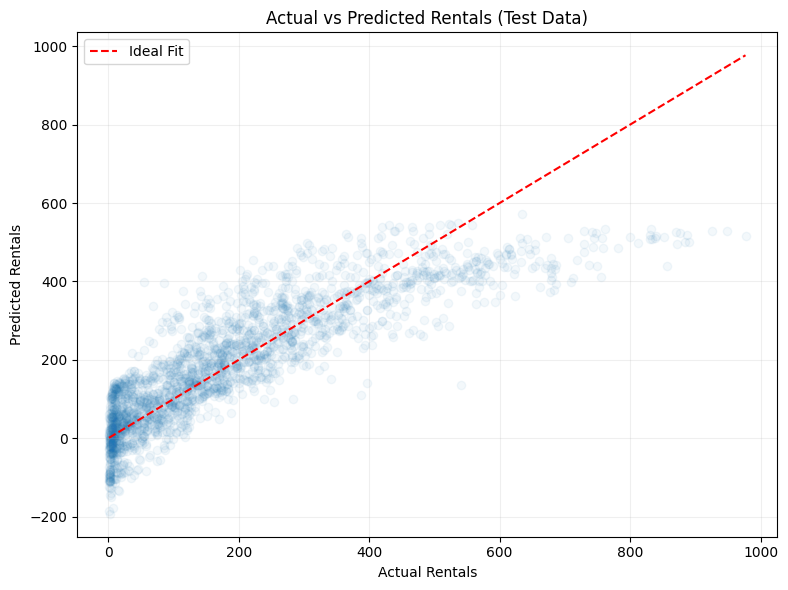

In [33]:
# Plot for test data: Actual vs Predicted Rentals
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.05)
plt.xlabel("Actual Rentals")
plt.ylabel("Predicted Rentals")
plt.title("Actual vs Predicted Rentals (Test Data)")

# Ideal line 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label="Ideal Fit")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Plot: Actual vs Predicted - Train Data**

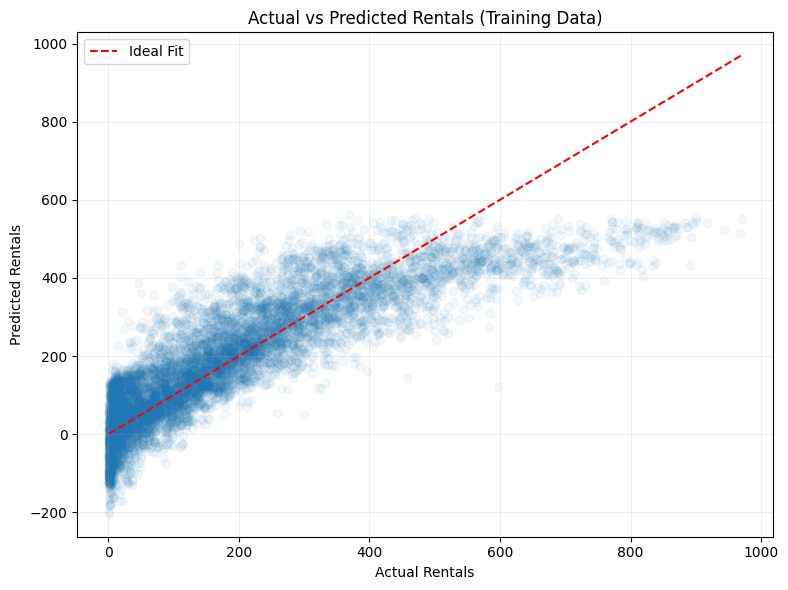

In [34]:
# Plot for training data: Actual vs Predicted Rentals
y_pred_train = model.predict(X_final_train)
plt.figure(figsize=(8, 6))

plt.scatter(y_train, y_pred_train, alpha=0.05)
plt.xlabel("Actual Rentals")
plt.ylabel("Predicted Rentals")
plt.title("Actual vs Predicted Rentals (Training Data)")

# Ideal line 
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color='red', linestyle='--', label="Ideal Fit")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Regression Results and discussion**

* The model is trained using selected features to predict bike rentals.

* The actual vs predicted plots (for both training and test data) show that the model follows the general trend, but there is still some spread around the ideal line.

* The model has an **R2 score of 0.7364**, **MSE of 8700.82**, and **RMSE of 93.28**, which shows a moderate fit.

* The model works better for middle values, but it has problems at very low and very high values. For high rental values, the model often predicts lower than the real value.

* For very low rental values, some predictions become negative, which is not realistic for rental counts. This happens because linear regression does not limit the output.

* The training and test plots look similar, which means the model is not overfitting. However, both plots still show clear errors.

* The error is larger for higher rental values because the linear model may be too simple to fully capture the complexity of the data. When rentals are high, the pattern becomes more complex, and the model cannot predict it well.

* The model is linear, but the real data is more complex and not fully linear. Feature engineering, such as converting the `hour` feature into cyclical variables and creating a new feature like `peak_period`, helps capture some patterns, but not all of them.

* In addition, the model does not capture interactions between features. For example, the effect of temperature may change depending on time or season, but a simple linear model cannot represent these combined effects well.

* Methods such as Ridge regression may help stabilize the model by reducing coefficient sensitivity, but they still assume a linear relationship and may not fully capture the complex patterns in the data.

* The model seems to have a limit, as predicted values do not go much higher after a certain point. This shows that the model cannot predict very high rental values well.

* These results suggest that a more flexible model is needed. Models like Random Forest or XGBoost can better handle complex patterns and may improve predictions, especially for high rental values.

* Overall, the model captures the general pattern, but it cannot fully explain all changes in bike rental demand.

## 13. Reflection / Conclusion

* In this project, the bike rental dataset was explored to better understand the factors associated with rental demand.  

* The analysis showed that time-related features and temperature-related variables were strongly associated with changes in bike rental activity.  

* Feature engineering played an important role in the project. Creating cyclical features for hour and the new feature `peak_period` helped capture time patterns more effectively.  
These features showed that bike demand tends to increase during specific periods of the day, such as morning and evening on working days and midday on non-working days.  

* However, the linear regression model has some limitations. It can produce negative predictions, which are not realistic for rental counts, and it assumes a linear relationship while real-world patterns are often more complex.  
This leads to larger errors, especially for higher rental values. In addition, the model cannot fully capture interactions between variables, such as how time and weather conditions affect rentals together.  

* This project also improved understanding of the overall data analysis workflow, including data cleaning, visualization, feature engineering, and regression modeling.  
It also highlighted the importance of thinking carefully about the structure of the data and how features represent real-world behavior.  

* In the future, more advanced models such as Random Forest or XGBoost could be used to better capture non-linear relationships and improve prediction performance.  

* Further improvements could also include creating additional features, tuning model parameters, and handling extreme values more carefully.